-0.75
-0.6710526315789473
-0.5921052631578947
-0.5131578947368421
-0.4342105263157895
-0.35526315789473684
-0.27631578947368424
-0.19736842105263164
-0.11842105263157898
-0.03947368421052633
0.03947368421052633
0.11842105263157887
0.19736842105263153
0.27631578947368407
0.3552631578947367
0.4342105263157894
0.513157894736842
0.5921052631578947
0.6710526315789473
0.75


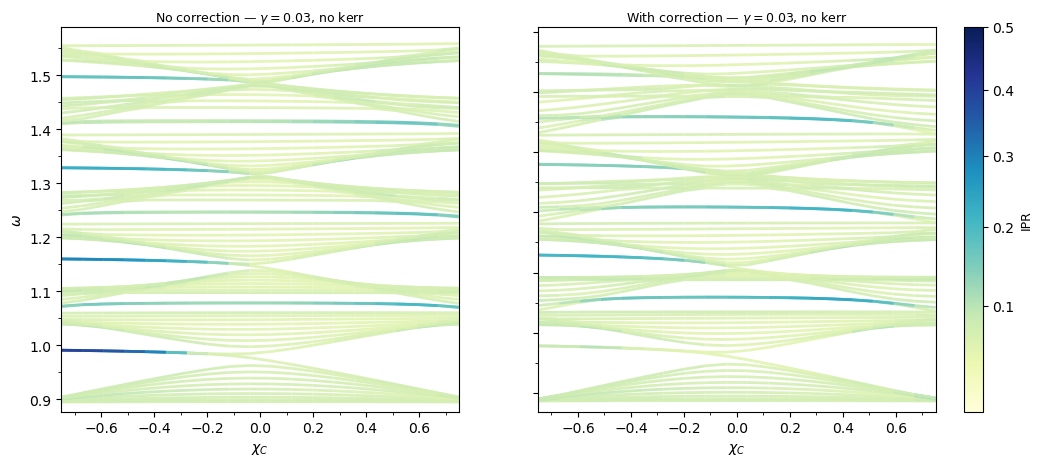

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import scipy.sparse.linalg as sla
import scipy.sparse as sp
from ssh_chain_sq import PHOTONICChain

# ------------------------------------------------------------------ #
# Kerr toggle -- set to None (or 0) to disable, or a float to enable.
# ------------------------------------------------------------------ #
KERR = None          # e.g. KERR = 0.05 to turn the Kerr term on
STATISTICS = 'boson'  # 'boson' or 'fermion' ('fermion' ignores KERR)


def make_edge_lifting_perturbation(chain, strength=1e-6):
    """
    Diagonal perturbation: delta_i = strength * (exp(-i/xi) - exp(-(2N-1-i)/xi))
    Positive on left edge sites, negative on right edge sites.
    Lifts the degeneracy without mixing the states significantly.
    """
    n = 2 * chain.N
    xi = n / 4.0
    d_ph = chain.fock_photon
    site_weights = np.array([np.exp(-i / xi) - np.exp(-(n - 1 - i) / xi)
                              for i in range(n)])
    # fock_states is a flat ndarray (fock_dim, 2N)
    diag_mat = chain.fock_states @ site_weights   # (fock_dim,)
    full_diag = strength * np.tile(diag_mat, d_ph)
    return sp.diags(full_diag, format='csr')


gap_threshold = 1e-4


def resolve_edge_states(chain, scale):
    H_pert = scale * (chain.H + make_edge_lifting_perturbation(chain, strength=1e-6))
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(H_pert, k=6, sigma=scale * sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies_scaled = np.array(sorted(results.keys()))
    all_energies_physical = all_energies_scaled / scale
    all_states = np.column_stack([results[e] for e in all_energies_scaled])

    near_mask = np.abs(all_energies_physical - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_energies_physical), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies_physical - 1.0))[:2]] = True

    V_near = all_states[:, near_mask]
    E_near = all_energies_physical[near_mask]
    if V_near.shape[1] > 2:
        best2 = np.argsort(np.abs(E_near - 1.0))[:2]
        V_near = V_near[:, best2]
        E_near = E_near[best2]

    e_order = np.argsort(E_near)
    V_sorted = V_near[:, e_order]
    return V_sorted[:, 0], V_sorted[:, 1]


# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N = 10
gamma_zero = 0.03
fock_photon = 8
Omega_J = 1.0
Chi_J = 0.0
base_excitations = 1
k_states = (8 * N - 1)
Omega_C = 0.2
Chi_C_values = np.linspace(-0.75, 0.75, 20)
PBC = False

# ------------------------------------------------------------------ #
# Compute spectra + IPR
# ------------------------------------------------------------------ #
energies_nosw, iprs_nosw = [], []
energies_sw, iprs_sw = [], []

for Chi_C in Chi_C_values:
    print(Chi_C)
    aux = 0.5 * Omega_C
    gamma = gamma_zero
    omega_r = 1.065 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
    scale = np.exp(10 * np.abs(Chi_C))

    chain = PHOTONICChain(N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r,
                           gamma=gamma, fock_photon=fock_photon,
                           Omega_J=Omega_J, Chi_J=Chi_J, kerr=KERR, PBC=PBC,
                           statistics=STATISTICS)
    chain.matter_hamiltonians(n_excitations=base_excitations)

    # ── no SW ────────────────────────────────────────────────────────
    chain.build_full_hamiltonian(sw=False)
    vals, vecs = chain.get_low_lying_spectrum(k=k_states)
    idx_sort = np.argsort(vals)
    vals = vals[idx_sort]
    vecs = vecs[:, idx_sort]
    try:
        evec_left, evec_right = resolve_edge_states(chain, scale)
        vecs[:, N - 1] = evec_left
        vecs[:, N] = evec_right
    except Exception:
        pass
    chain.build_squeezed_vacuum(truncation=1)
    chain.warm_old_basis_cache()
    energies_nosw.append(vals)
    iprs_nosw.append(chain.compute_ipr_batch(vecs))

    # ── with SW ──────────────────────────────────────────────────────
    chain.build_full_hamiltonian(sw=True)
    vals, vecs = chain.get_low_lying_spectrum(k=k_states)
    idx_sort = np.argsort(vals)
    vals = vals[idx_sort]
    vecs = vecs[:, idx_sort]
    try:
        evec_left, evec_right = resolve_edge_states(chain, scale)
        vecs[:, N - 1] = evec_left
        vecs[:, N] = evec_right
    except Exception:
        pass
    chain.build_squeezed_vacuum(truncation=1)
    chain.warm_old_basis_cache()
    energies_sw.append(vals)
    iprs_sw.append(chain.compute_ipr_batch(vecs))

energies_nosw = np.array(energies_nosw)   # (n_Chi, k_states)
iprs_nosw = np.array(iprs_nosw)
energies_sw = np.array(energies_sw)
iprs_sw = np.array(iprs_sw)

# ------------------------------------------------------------------ #
# Figure 1: spectrum colored by IPR, with vs without SW
# ------------------------------------------------------------------ #
cmap = plt.cm.YlGnBu
ipr_min = 1e-4
ipr_max = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
datasets = [
    (axes[0], energies_nosw, iprs_nosw, "No correction"),
    (axes[1], energies_sw, iprs_sw, "With correction"),
]
for ax, energies, iprs, title in datasets:
    for band_e, band_ipr in zip(energies.T, iprs.T):
        points = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                             linewidth=2.0, alpha=0.9)
        lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
        ax.add_collection(lc)
    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = energies.flatten()
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.set_xlabel(r'$\chi_C$')
    kerr_label = f", kerr={KERR}" if KERR else ", no kerr"
    ax.set_title(rf'{title} — $\gamma = {gamma_zero:.2f}${kerr_label}', fontsize=9, pad=4)

axes[0].set_ylabel(r'$\omega$')
axes[1].tick_params(labelleft=False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.03, pad=0.03)
cbar.set_label(r'IPR', fontsize=9)
plt.show()

# ------------------------------------------------------------------ #
# Figure 2: full Hamiltonian matrix (last Chi_C value in the sweep)
# ------------------------------------------------------------------ #
# chain.build_full_hamiltonian()
# hc_dense = np.real(chain.H.toarray())

# fig, ax1 = plt.subplots(1, 1, figsize=(12, 5))
# im1 = ax1.matshow(hc_dense, cmap='viridis')
# ax1.set_title("$H$" + (f" (kerr={KERR})" if KERR else " (no kerr)"), pad=15)
# fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------------ #
# # Figure 3: off-diagonal H vs SW correction matrix (last Chi_C value)
# # ------------------------------------------------------------------ #
# chain.build_full_hamiltonian()
# chain.schrieffer_wolff_correction()

# hc_dense = np.real(chain.H.toarray())
# hc_offdiag = hc_dense - np.diag(np.diag(hc_dense))
# abs_max_c = np.max(np.abs(hc_offdiag))
# if abs_max_c == 0:
#     abs_max_c = 1e-15

# hj_dense = np.real(chain.H_SW.toarray())
# abs_max_j = np.max(np.abs(hj_dense))
# if abs_max_j == 0:
#     abs_max_j = 1e-15

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# im1 = ax1.matshow(hc_offdiag, cmap='seismic', vmin=-abs_max_c, vmax=abs_max_c)
# ax1.set_title("$H$ (Non diag)", pad=15)
# fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# im2 = ax2.matshow(hj_dense, cmap='seismic', vmin=-abs_max_j, vmax=abs_max_j)
# ax2.set_title(r"$H_{\text{correction}}$" + (f", kerr={KERR}" if KERR else ", no kerr"), pad=15)
# fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

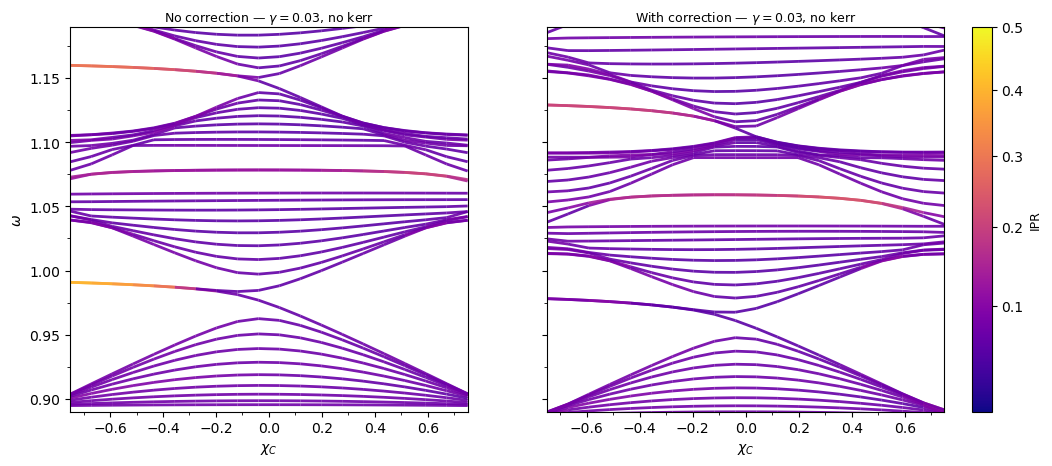

In [24]:
# ------------------------------------------------------------------ #
# Figure 1: spectrum colored by IPR, with vs without SW
# ------------------------------------------------------------------ #
# cmap = plt.cm.YlGnBu
cmap = plt.cm.plasma

ipr_min = 1e-4
ipr_max = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
datasets = [
    (axes[0], energies_nosw, iprs_nosw, "No correction"),
    (axes[1], energies_sw, iprs_sw, "With correction"),
]
for ax, energies, iprs, title in datasets:
    for band_e, band_ipr in zip(energies.T, iprs.T):
        points = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                             linewidth=2.0, alpha=0.9)
        lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
        ax.add_collection(lc)
    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = energies.flatten()
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.set_xlabel(r'$\chi_C$')
    kerr_label = f", kerr={KERR}" if KERR else ", no kerr"
    ax.set_title(rf'{title} — $\gamma = {gamma_zero:.2f}${kerr_label}', fontsize=9, pad=4)

axes[0].set_ylabel(r'$\omega$')
axes[1].tick_params(labelleft=False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.03, pad=0.03)
cbar.set_label(r'IPR', fontsize=9)
axes[0].set_ylim(0.89, 1.19)
axes[1].set_ylim(0.89, 1.19)
plt.show()

In [38]:
# ------------------------------------------------------------------ #
# Cell 1: uncoupled (gamma = 0) reference simulation
# ------------------------------------------------------------------ #
energies_nosw_g0, energies_sw_g0 = [], []

for Chi_C in Chi_C_values:
    aux = 0.5 * Omega_C
    gamma = 0.0   # <-- decoupled
    omega_r = 1.065 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
    scale = np.exp(10 * np.abs(Chi_C))

    chain_g0 = PHOTONICChain(N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r,
                              gamma=gamma, fock_photon=fock_photon,
                              Omega_J=Omega_J, Chi_J=Chi_J, kerr=KERR, PBC=PBC,
                              statistics=STATISTICS)
    chain_g0.matter_hamiltonians(n_excitations=base_excitations)

    chain_g0.build_full_hamiltonian(sw=False)
    vals, _ = chain_g0.get_low_lying_spectrum(k=k_states)
    energies_nosw_g0.append(np.sort(vals))

    chain_g0.build_full_hamiltonian(sw=True)
    vals, _ = chain_g0.get_low_lying_spectrum(k=k_states)
    energies_sw_g0.append(np.sort(vals))

energies_nosw_g0 = np.array(energies_nosw_g0)
energies_sw_g0   = np.array(energies_sw_g0)

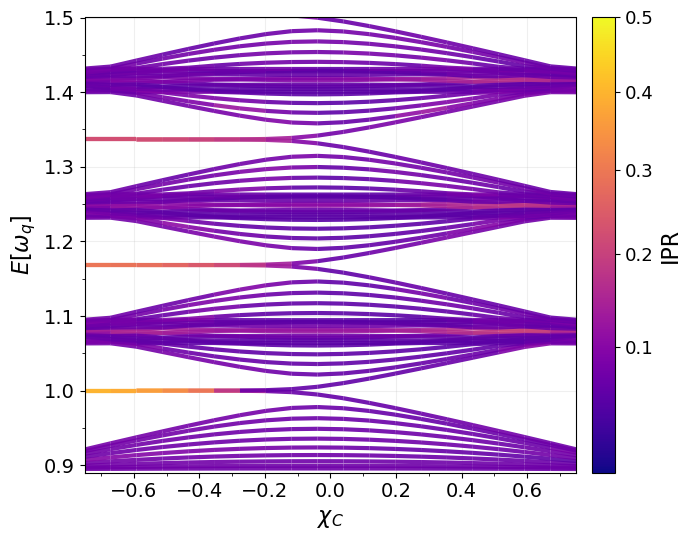

In [41]:
# ------------------------------------------------------------------ #
# Figure: uncoupled (gamma = 0) spectrum, "No correction", IPR-colored
# ------------------------------------------------------------------ #
cmap = plt.cm.plasma
ipr_min = 1e-4
ipr_max = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)
fs = 16

fig, ax = plt.subplots(figsize=(7, 5.5))

for band_e, band_ipr in zip(energies_nosw_g0.T, iprs_nosw.T):
    points = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                         linewidth=3.0, alpha=0.9)
    lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
    ax.add_collection(lc)

ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
ax.set_ylim(0.89, 1.5)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.set_xlabel(r'$\chi_C$', fontsize=fs)
ax.set_ylabel(r'$E[\omega_q]$', fontsize=fs)
ax.tick_params(labelsize=fs - 2)
ax.grid(True, alpha=0.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.03)
cbar.set_label(r'IPR', fontsize=fs)
cbar.ax.tick_params(labelsize=fs - 3)

fig.tight_layout()
# fig.savefig('spectrum_g0_nosw_ipr.pdf', bbox_inches='tight')
plt.show()

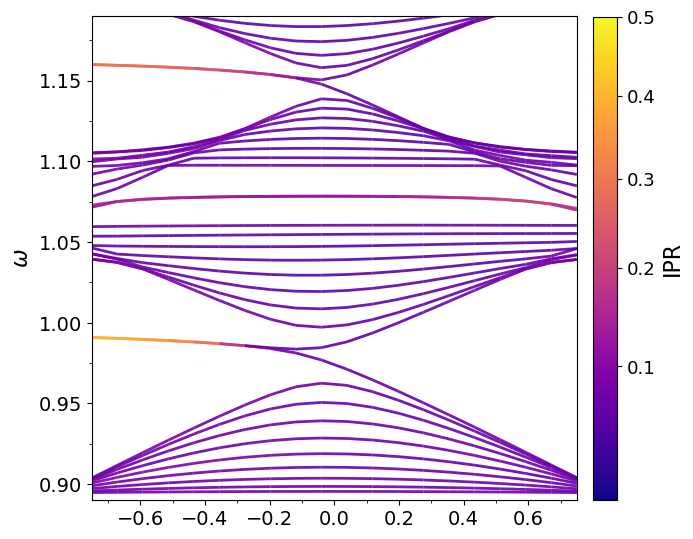

In [35]:
# ------------------------------------------------------------------ #
# Cell 2: Figure — "No correction", coupled (IPR-colored) vs uncoupled (dashed)
# ------------------------------------------------------------------ #
cmap = plt.cm.plasma
ipr_min = 1e-4
ipr_max = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)

fs = 16   # base fontsize

fig, ax = plt.subplots(figsize=(7, 5.5))

# coupled spectrum, colored by IPR
for band_e, band_ipr in zip(energies_nosw.T, iprs_nosw.T):
    points = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                         linewidth=2.0, alpha=0.9)
    lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
    ax.add_collection(lc)

ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
ax.set_ylim(0.89, 1.19)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.set_ylabel(r'$E[\omega_q]$', fontsize=fs)
ax.set_ylabel(r'$\omega$', fontsize=fs)
ax.tick_params(labelsize=fs - 2)

kerr_label = f", kerr={KERR}" if KERR else ", no kerr"

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.03)
cbar.set_label(r'IPR', fontsize=fs)
cbar.ax.tick_params(labelsize=fs - 3)

fig.tight_layout()
# fig.savefig('spectrum_nosw_vs_g0.pdf', bbox_inches='tight')
plt.show()

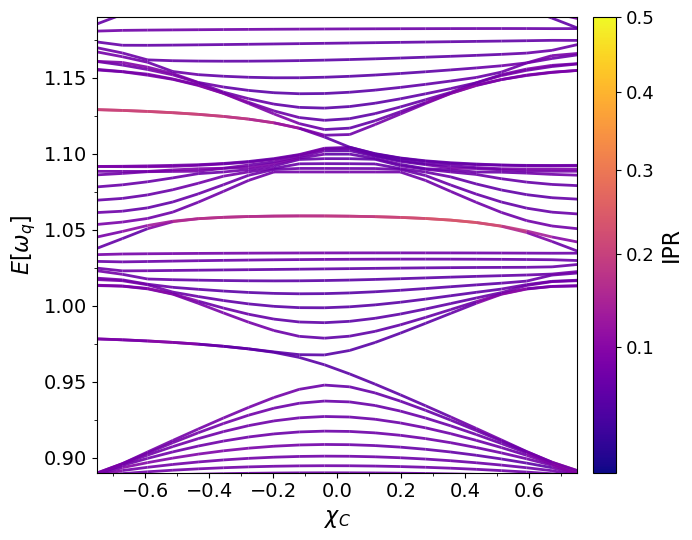

In [34]:
# ------------------------------------------------------------------ #
# Cell 3: Figure — "With correction", coupled (IPR-colored) vs uncoupled (dashed)
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(7, 5.5))

# coupled spectrum, colored by IPR
for band_e, band_ipr in zip(energies_sw.T, iprs_sw.T):
    points = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                         linewidth=2.0, alpha=0.9)
    lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
    ax.add_collection(lc)

ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
ax.set_ylim(0.89, 1.19)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

ax.set_xlabel(r'$\chi_C$', fontsize=fs)
ax.set_ylabel(r'$E[\omega_q]$', fontsize=fs)
ax.tick_params(labelsize=fs - 2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.03)
cbar.set_label(r'IPR', fontsize=fs)
cbar.ax.tick_params(labelsize=fs - 3)

fig.tight_layout()
# fig.savefig('spectrum_sw_vs_g0.pdf', bbox_inches='tight')
plt.show()

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import scipy.sparse.linalg as sla
import scipy.sparse as sp
from ssh_chain_sq import PHOTONICChain

# ------------------------------------------------------------------ #
# Kerr toggle -- set to None (or 0) to disable, or a float to enable.
# ------------------------------------------------------------------ #
KERR = 0.05         # e.g. KERR = 0.05 to turn the Kerr term on
STATISTICS = 'boson'  # 'boson' or 'fermion' ('fermion' ignores KERR)


def make_edge_lifting_perturbation(chain, strength=1e-6):
    """
    Diagonal perturbation: delta_i = strength * (exp(-i/xi) - exp(-(2N-1-i)/xi))
    Positive on left edge sites, negative on right edge sites.
    Lifts the degeneracy without mixing the states significantly.
    """
    n = 2 * chain.N
    xi = n / 4.0
    d_ph = chain.fock_photon
    site_weights = np.array([np.exp(-i / xi) - np.exp(-(n - 1 - i) / xi)
                              for i in range(n)])
    # fock_states is a flat ndarray (fock_dim, 2N)
    diag_mat = chain.fock_states @ site_weights   # (fock_dim,)
    full_diag = strength * np.tile(diag_mat, d_ph)
    return sp.diags(full_diag, format='csr')


gap_threshold = 1e-4


def resolve_edge_states(chain, scale):
    H_pert = scale * (chain.H + make_edge_lifting_perturbation(chain, strength=1e-6))
    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(H_pert, k=6, sigma=scale * sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies_scaled = np.array(sorted(results.keys()))
    all_energies_physical = all_energies_scaled / scale
    all_states = np.column_stack([results[e] for e in all_energies_scaled])

    near_mask = np.abs(all_energies_physical - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_energies_physical), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies_physical - 1.0))[:2]] = True

    V_near = all_states[:, near_mask]
    E_near = all_energies_physical[near_mask]
    if V_near.shape[1] > 2:
        best2 = np.argsort(np.abs(E_near - 1.0))[:2]
        V_near = V_near[:, best2]
        E_near = E_near[best2]

    e_order = np.argsort(E_near)
    V_sorted = V_near[:, e_order]
    return V_sorted[:, 0], V_sorted[:, 1]


# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N = 26
gamma_zero = 0.05
fock_photon = 8
Omega_J = 1.0
Chi_J = 0.0
base_excitations = 1
k_states = (8 * N - 1)
Omega_C = 0.2
Chi_C_values = np.linspace(-0.75, 0.75, 20)
PBC = False

# ------------------------------------------------------------------ #
# Compute spectra + IPR
# ------------------------------------------------------------------ #
energies_nosw, iprs_nosw = [], []
energies_sw, iprs_sw = [], []

for Chi_C in Chi_C_values:
    print(Chi_C)
    aux = 0.5 * Omega_C
    gamma = gamma_zero
    omega_r = 1.03 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
    scale = np.exp(10 * np.abs(Chi_C))

    chain = PHOTONICChain(N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r,
                           gamma=gamma, fock_photon=fock_photon,
                           Omega_J=Omega_J, Chi_J=Chi_J, kerr=KERR, PBC=PBC,
                           statistics=STATISTICS)
    chain.matter_hamiltonians(n_excitations=base_excitations)

    # ── no SW ────────────────────────────────────────────────────────
    chain.build_full_hamiltonian(sw=False)
    vals, vecs = chain.get_low_lying_spectrum(k=k_states)
    idx_sort = np.argsort(vals)
    vals = vals[idx_sort]
    vecs = vecs[:, idx_sort]
    try:
        evec_left, evec_right = resolve_edge_states(chain, scale)
        vecs[:, N - 1] = evec_left
        vecs[:, N] = evec_right
    except Exception:
        pass
    chain.build_squeezed_vacuum(truncation=1)
    chain.warm_old_basis_cache()
    energies_nosw.append(vals)
    iprs_nosw.append(chain.compute_ipr_batch(vecs))

    # ── with SW ──────────────────────────────────────────────────────
    chain.build_full_hamiltonian(sw=True)
    vals, vecs = chain.get_low_lying_spectrum(k=k_states)
    idx_sort = np.argsort(vals)
    vals = vals[idx_sort]
    vecs = vecs[:, idx_sort]
    try:
        evec_left, evec_right = resolve_edge_states(chain, scale)
        vecs[:, N - 1] = evec_left
        vecs[:, N] = evec_right
    except Exception:
        pass
    chain.build_squeezed_vacuum(truncation=1)
    chain.warm_old_basis_cache()
    energies_sw.append(vals)
    iprs_sw.append(chain.compute_ipr_batch(vecs))

energies_nosw = np.array(energies_nosw)   # (n_Chi, k_states)
iprs_nosw = np.array(iprs_nosw)
energies_sw = np.array(energies_sw)
iprs_sw = np.array(iprs_sw)

# ------------------------------------------------------------------ #
# Figure 1: spectrum colored by IPR, with vs without SW
# ------------------------------------------------------------------ #
cmap = plt.cm.YlGnBu
ipr_min = 1e-4
ipr_max = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
datasets = [
    (axes[0], energies_nosw, iprs_nosw, "No correction"),
    (axes[1], energies_sw, iprs_sw, "With correction"),
]
for ax, energies, iprs, title in datasets:
    for band_e, band_ipr in zip(energies.T, iprs.T):
        points = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                             linewidth=2.0, alpha=0.9)
        lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
        ax.add_collection(lc)
    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = energies.flatten()
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.set_xlabel(r'$\chi_C$')
    kerr_label = f", kerr={KERR}" if KERR else ", no kerr"
    ax.set_title(rf'{title} — $\gamma = {gamma_zero:.2f}${kerr_label}', fontsize=9, pad=4)

axes[0].set_ylabel(r'$\omega$')
axes[1].tick_params(labelleft=False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.03, pad=0.03)
cbar.set_label(r'IPR', fontsize=9)
plt.show()

# ------------------------------------------------------------------ #
# Figure 2: full Hamiltonian matrix (last Chi_C value in the sweep)
# ------------------------------------------------------------------ #
chain.build_full_hamiltonian()
hc_dense = np.real(chain.H.toarray())

fig, ax1 = plt.subplots(1, 1, figsize=(12, 5))
im1 = ax1.matshow(hc_dense, cmap='viridis')
ax1.set_title("$H$" + (f" (kerr={KERR})" if KERR else " (no kerr)"), pad=15)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------ #
# Figure 3: off-diagonal H vs SW correction matrix (last Chi_C value)
# ------------------------------------------------------------------ #
chain.build_full_hamiltonian()
chain.schrieffer_wolff_correction()

hc_dense = np.real(chain.H.toarray())
hc_offdiag = hc_dense - np.diag(np.diag(hc_dense))
abs_max_c = np.max(np.abs(hc_offdiag))
if abs_max_c == 0:
    abs_max_c = 1e-15

hj_dense = np.real(chain.H_SW.toarray())
abs_max_j = np.max(np.abs(hj_dense))
if abs_max_j == 0:
    abs_max_j = 1e-15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax1.matshow(hc_offdiag, cmap='seismic', vmin=-abs_max_c, vmax=abs_max_c)
ax1.set_title("$H$ (Non diag)", pad=15)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

im2 = ax2.matshow(hj_dense, cmap='seismic', vmin=-abs_max_j, vmax=abs_max_j)
ax2.set_title(r"$H_{\text{correction}}$" + (f", kerr={KERR}" if KERR else ", no kerr"), pad=15)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

-0.75


KeyboardInterrupt: 

In [3]:
"""
Profiles PHOTONICChain construction + SW correction with and without the
Kerr term, using lightweight timing instrumentation added to __init__ and
build_HC_fock (self._init_timings, self._hc_fock_timings).
"""
import time
import numpy as np
from ssh_chain_sq_PROFILED import PHOTONICChain


def profile_run(label, kerr, N=6, Omega_C=0.2, Chi_C=0.3, omega_r=1.0, gamma=0.05,
                 fock_photon=8, Omega_J=1.0, Chi_J=0.0, PBC=True, n_excitations=1):
    print(f"\n=== {label} (kerr={kerr}, N={N}, n_excitations={n_excitations}) ===")

    t0 = time.perf_counter()
    chain = PHOTONICChain(N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r,
                           gamma=gamma, fock_photon=fock_photon,
                           Omega_J=Omega_J, Chi_J=Chi_J, kerr=kerr, PBC=PBC,
                           statistics='boson')
    t_init = time.perf_counter() - t0
    print(f"  __init__ total:                {t_init:.4f}s")

    if hasattr(chain, '_init_timings'):
        for k, v in chain._init_timings.items():
            print(f"    - {k:<22s}: {v:.4f}s")

    t0 = time.perf_counter()
    chain.matter_hamiltonians(n_excitations=n_excitations)
    t_matter = time.perf_counter() - t0
    print(f"  matter_hamiltonians:            {t_matter:.4f}s")

    t0 = time.perf_counter()
    chain.build_full_hamiltonian()
    t_full = time.perf_counter() - t0
    print(f"  build_full_hamiltonian:         {t_full:.4f}s")

    t0 = time.perf_counter()
    chain.schrieffer_wolff_correction()
    t_sw = time.perf_counter() - t0
    print(f"  schrieffer_wolff_correction:    {t_sw:.4f}s")

    if hasattr(chain, '_hc_fock_timings'):
        print(f"  build_HC_fock Kerr-branch calls: {len(chain._hc_fock_timings)}")
        for i, entry in enumerate(chain._hc_fock_timings):
            print(f"    call {i}: n_total={entry['n_total']:<5d} "
                  f"build_operator_matrix={entry['build_operator_matrix']:.4f}s  "
                  f"eigh={entry['eigh']:.4f}s")
        total_eigh = sum(e['eigh'] for e in chain._hc_fock_timings)
        total_kop = sum(e['build_operator_matrix'] for e in chain._hc_fock_timings)
        print(f"  build_HC_fock totals:  eigh={total_eigh:.4f}s  "
              f"build_operator_matrix={total_kop:.4f}s")

    grand_total = t_init + t_matter + t_full + t_sw
    print(f"  GRAND TOTAL:                    {grand_total:.4f}s")
    return grand_total


if __name__ == "__main__":
    t_none = profile_run("No Kerr", kerr=None)
    t_kerr = profile_run("Kerr active", kerr=0.05)

    print(f"\n=== Summary ===")
    print(f"  no kerr total:  {t_none:.4f}s")
    print(f"  kerr total:     {t_kerr:.4f}s")
    print(f"  slowdown factor: {t_kerr / t_none:.2f}x")


=== No Kerr (kerr=None, N=6, n_excitations=1) ===
  __init__ total:                0.0015s
    - diagonalize_1         : 0.0014s
  matter_hamiltonians:            0.0025s
  build_full_hamiltonian:         0.0020s
  schrieffer_wolff_correction:    0.0131s
  GRAND TOTAL:                    0.0192s

=== Kerr active (kerr=0.05, N=6, n_excitations=1) ===
  __init__ total:                0.0121s
    - diagonalize_1         : 0.0014s
    - kerr_change_basis_1   : 0.0058s
    - diagonalize_2         : 0.0012s
    - kerr_change_basis_2   : 0.0034s
  matter_hamiltonians:            0.0024s
  build_full_hamiltonian:         0.0019s
  schrieffer_wolff_correction:    4.2585s
  build_HC_fock Kerr-branch calls: 1
    call 0: n_total=364   build_operator_matrix=4.1974s  eigh=0.0416s
  build_HC_fock totals:  eigh=0.0416s  build_operator_matrix=4.1974s
  GRAND TOTAL:                    4.2750s

=== Summary ===
  no kerr total:  0.0192s
  kerr total:     4.2750s
  slowdown factor: 222.98x


In [4]:
"""
Verifies the vectorized boson fast path in build_sparse_operator_matrix
(_build_operator_matrix_vectorized_boson) is bit-identical to the original
dict-based per-column construction, across:
  - a quadratic (1,0) operator
  - a rank-4 Kerr-like (1,1,0,0) operator with a DENSE tensor (the actual
    failure mode that motivated this optimization)
  - the real Kerr operator extracted from an actual PHOTONICChain instance
"""
import numpy as np
from collections import defaultdict
from sq_engine import SecondQuantizationEngine, QuantumOperator, TensorTerm, Superposition


def reference_build_sparse(eng, operator, basis):
    """The original, unoptimized, dict-based per-column construction --
    used here purely as a ground truth, not as production code."""
    dim = len(basis)
    matrix = np.zeros((dim, dim), dtype=complex)
    state_to_index = {s: i for i, s in enumerate(basis)}
    for col_idx, ket in enumerate(basis):
        sup = Superposition({ket: 1.0 + 0j})
        result = eng.apply_operator(operator, sup)
        for rs, amp in result.states.items():
            if rs in state_to_index and abs(amp) > eng.coeff_tol:
                matrix[state_to_index[rs], col_idx] += amp
    return matrix


def test_quadratic_operator():
    np.random.seed(0)
    n = 5
    A = np.random.randn(n, n) * 0.3
    op = QuantumOperator([TensorTerm(A, (1, 0))])
    eng = SecondQuantizationEngine(n_modes=n, statistics='boson')
    basis = [tuple(s) for s in eng.generate_basis(2) + eng.generate_basis(3)]

    ref = reference_build_sparse(eng, op, basis)
    fast = eng.build_sparse_operator_matrix(op, basis).toarray()

    assert np.allclose(ref, fast, atol=1e-10), \
        f"max diff {np.max(np.abs(ref - fast))}"
    print("PASS: quadratic (1,0) operator matches reference")


def test_dense_kerr_like_operator():
    np.random.seed(1)
    n = 5
    tensor = np.random.randn(n, n, n, n) * 0.05
    op = QuantumOperator([TensorTerm(tensor, (1, 1, 0, 0))])
    eng = SecondQuantizationEngine(n_modes=n, statistics='boson')
    basis = [tuple(s) for s in eng.generate_basis(2) + eng.generate_basis(3) + eng.generate_basis(4)]

    ref = reference_build_sparse(eng, op, basis)
    fast = eng.build_sparse_operator_matrix(op, basis).toarray()

    max_diff = np.max(np.abs(ref - fast))
    assert np.allclose(ref, fast, atol=1e-10), f"max diff {max_diff}"
    print(f"PASS: dense rank-4 (1,1,0,0) operator matches reference (max diff {max_diff:.2e})")


def test_real_kerr_operator_from_chain():
    from ssh_chain_sq import PHOTONICChain

    chain = PHOTONICChain(N=4, Omega_C=0.2, Chi_C=0.3, omega_r=1.0, gamma=0.05,
                           fock_photon=4, Omega_J=1.0, Chi_J=0.0, kerr=0.05,
                           PBC=True, statistics='boson')
    eng = chain.engine
    op = QuantumOperator([chain.kerr_operator])
    basis = [tuple(s) for s in eng.generate_basis(3)]

    ref = reference_build_sparse(eng, op, basis)
    fast = eng.build_sparse_operator_matrix(op, basis).toarray()

    max_diff = np.max(np.abs(ref - fast))
    assert np.allclose(ref, fast, atol=1e-8), f"max diff {max_diff}"
    print(f"PASS: real Kerr operator from PHOTONICChain matches reference "
          f"(basis dim {len(basis)}, max diff {max_diff:.2e})")


def test_fermion_falls_back_correctly():
    """Fermions should NOT use the vectorized boson path -- confirm the
    fallback per-column path (with Jordan-Wigner phase) still matches."""
    np.random.seed(2)
    n = 5
    M = np.random.randn(n, n)
    A = 0.5 * (M + M.T)
    op = QuantumOperator([TensorTerm(A, (1, 0))])
    eng = SecondQuantizationEngine(n_modes=n, statistics='fermion')
    basis = [tuple(s) for s in eng.generate_basis(2)]

    ref = reference_build_sparse(eng, op, basis)
    fast = eng.build_sparse_operator_matrix(op, basis).toarray()

    assert np.allclose(ref, fast, atol=1e-10)
    print("PASS: fermion path (no vectorized fast path applied) still matches reference")


if __name__ == "__main__":
    test_quadratic_operator()
    test_dense_kerr_like_operator()
    test_real_kerr_operator_from_chain()
    test_fermion_falls_back_correctly()
    print("\nALL PASS")

PASS: quadratic (1,0) operator matches reference
PASS: dense rank-4 (1,1,0,0) operator matches reference (max diff 2.22e-16)
PASS: real Kerr operator from PHOTONICChain matches reference (basis dim 120, max diff 8.56e-17)
PASS: fermion path (no vectorized fast path applied) still matches reference

ALL PASS


In [1]:
"""
Verifies the vectorized boson fast path in build_squeezed_vacuum
(_build_squeezed_vacuum_vectorized_boson) is bit-identical to the original
dict-based per-level construction, including the i==j edge case (a single
mode hit twice within one (i,j) pair application) and across several
truncation levels and system sizes.
"""
import numpy as np
from collections import defaultdict
from sq_engine import SecondQuantizationEngine, Superposition


def reference_build_squeezed_vacuum(eng, U, V, truncation, threshold=0.99):
    """Original dict-based implementation, used as ground truth only."""
    n = eng.n_modes
    U_V = np.vstack([U, V])
    tau_x = np.block([[np.zeros((n, n)), np.eye(n)], [np.eye(n), np.zeros((n, n))]])
    J_U_V = tau_x @ U_V.conj()
    P = np.hstack([U_V, J_U_V])
    P_inv = np.linalg.inv(P)
    U_tilde = P_inv[:n, :n]
    V_tilde = P_inv[:n, n:]
    M = np.linalg.solve(U_tilde, V_tilde)

    vacuum = tuple([0] * n)
    current_terms = {vacuum: 1.0 + 0j}
    final_state = defaultdict(complex)
    final_state[vacuum] = 1.0 + 0j

    for k in range(1, truncation + 1):
        next_terms = defaultdict(complex)
        for state_tuple, coeff in current_terms.items():
            state = list(state_tuple)
            for j in range(n):
                for i in range(n):
                    val = M[i, j]
                    if abs(val) < eng.coeff_tol:
                        continue
                    new_state = state.copy()
                    new_state[j] += 1
                    factor_j = np.sqrt(new_state[j])
                    new_state[i] += 1
                    factor_i = np.sqrt(new_state[i])
                    next_terms[tuple(new_state)] += coeff * (-0.5) * val * factor_j * factor_i / float(k)
        for st, val in next_terms.items():
            if abs(val) > eng.coeff_tol:
                final_state[st] += val
        current_terms = next_terms

    return Superposition(final_state).trim(threshold)


def compare_superpositions(sup_a, sup_b, atol=1e-8):
    keys = set(sup_a.states) | set(sup_b.states)
    max_diff = 0.0
    for k in keys:
        a = sup_a.states.get(k, 0.0)
        b = sup_b.states.get(k, 0.0)
        max_diff = max(max_diff, abs(a - b))
    return max_diff


def test_small_system_multiple_truncations():
    np.random.seed(0)
    n = 4
    eng = SecondQuantizationEngine(n_modes=n, statistics='boson')

    # Build a small, valid pseudo-unitary-ish (U, V) pair via a random
    # quadratic Hamiltonian through the real diagonalize_quadratic path,
    # so U, V are physically valid (not arbitrary matrices).
    from sq_engine import QuantumOperator, TensorTerm
    T = np.zeros((n, n))
    vals = [0.3, 0.15, 0.3]
    for j in range(n - 1):
        T[j, j+1] = T[j+1, j] = vals[j]
    A = 0.5 * (np.eye(n) + T)
    B = -0.5 * T
    op = QuantumOperator([TensorTerm(A, (1, 0)), TensorTerm(B, (1, 1))])
    _, U, V = eng.diagonalize_quadratic(op)

    for truncation in [1, 2, 3, 4]:
        ref = reference_build_squeezed_vacuum(eng, U, V, truncation)
        fast = eng._build_squeezed_vacuum_vectorized_boson(U, V, truncation)
        diff = compare_superpositions(ref, fast)
        assert diff < 1e-8, f"truncation={truncation}: max diff {diff}"
        print(f"PASS: truncation={truncation}, n={n} -- max diff {diff:.2e}, "
              f"{len(ref.states)} states")


def test_larger_system():
    n = 8
    eng = SecondQuantizationEngine(n_modes=n, statistics='boson')
    from sq_engine import QuantumOperator, TensorTerm
    Omega_C, Chi_C = 0.2, 0.3
    gc1 = 0.25 * Omega_C * (1 + Chi_C)
    gc2 = 0.25 * Omega_C * (1 - Chi_C)
    T = np.zeros((n, n))
    for j in range(n - 1):
        T[j, j+1] = T[j+1, j] = gc1 if j % 2 == 0 else gc2
    A = 0.5 * (np.eye(n) + T)
    B = -0.5 * T
    op = QuantumOperator([TensorTerm(A, (1, 0)), TensorTerm(B, (1, 1))])
    _, U, V = eng.diagonalize_quadratic(op)

    for truncation in [2, 3]:
        ref = reference_build_squeezed_vacuum(eng, U, V, truncation)
        fast = eng._build_squeezed_vacuum_vectorized_boson(U, V, truncation)
        diff = compare_superpositions(ref, fast)
        assert diff < 1e-8, f"truncation={truncation}: max diff {diff}"
        print(f"PASS: n={n}, truncation={truncation} -- max diff {diff:.2e}, "
              f"{len(ref.states)} states")


def test_real_chain_vacuum():
    from ssh_chain_sq import PHOTONICChain

    chain = PHOTONICChain(N=6, Omega_C=0.2, Chi_C=0.3, omega_r=1.0, gamma=0.05,
                           fock_photon=8, Omega_J=1.0, Chi_J=0.0, kerr=None,
                           PBC=True, statistics='boson')
    eng = chain.engine

    for truncation in [2, 3, 4]:
        ref = reference_build_squeezed_vacuum(eng, chain.U, chain.V, truncation)
        fast = eng._build_squeezed_vacuum_vectorized_boson(chain.U, chain.V, truncation)
        diff = compare_superpositions(ref, fast)
        assert diff < 1e-8, f"truncation={truncation}: max diff {diff}"
        print(f"PASS: real chain N=6, truncation={truncation} -- max diff {diff:.2e}, "
              f"{len(ref.states)} states")


def test_dispatch_through_public_method():
    """Confirm build_squeezed_vacuum itself dispatches correctly for bosons."""
    from ssh_chain_sq import PHOTONICChain

    chain = PHOTONICChain(N=4, Omega_C=0.2, Chi_C=0.3, omega_r=1.0, gamma=0.05,
                           fock_photon=4, Omega_J=1.0, Chi_J=0.0, kerr=None,
                           PBC=False, statistics='boson')
    eng = chain.engine
    ref = reference_build_squeezed_vacuum(eng, chain.U, chain.V, truncation=3)
    via_public = eng.build_squeezed_vacuum(chain.U, chain.V, truncation=3)
    diff = compare_superpositions(ref, via_public)
    assert diff < 1e-8
    print(f"PASS: public build_squeezed_vacuum dispatches to vectorized path correctly")


if __name__ == "__main__":
    test_small_system_multiple_truncations()
    test_larger_system()
    test_real_chain_vacuum()
    test_dispatch_through_public_method()
    print("\nALL PASS")

PASS: truncation=1, n=4 -- max diff 1.11e-16, 5 states
PASS: truncation=2, n=4 -- max diff 1.11e-16, 8 states
PASS: truncation=3, n=4 -- max diff 1.39e-17, 9 states
PASS: truncation=4, n=4 -- max diff 2.22e-16, 9 states
PASS: n=8, truncation=2 -- max diff 0.00e+00, 1 states
PASS: n=8, truncation=3 -- max diff 0.00e+00, 1 states
PASS: real chain N=6, truncation=2 -- max diff 0.00e+00, 1 states
PASS: real chain N=6, truncation=3 -- max diff 0.00e+00, 1 states
PASS: real chain N=6, truncation=4 -- max diff 0.00e+00, 1 states
PASS: public build_squeezed_vacuum dispatches to vectorized path correctly

ALL PASS


In [3]:
"""
Step 1 benchmark (per the GPU handoff plan) for
SecondQuantizationEngine._build_squeezed_vacuum_vectorized_boson.

Run this on a machine with an actual GPU + cupy installed. It does NOT
modify sq_engine.py or ssh_chain_sq.py -- it is a standalone diagnostic
that imports the real engine purely to extract realistic
(current_states, current_coeffs, nz_i, nz_j, nz_val) inputs at each
truncation level, matching what the function actually processes for a
real PHOTONICChain at N=8 (16 modes), the size used in the original
profiling table.

Usage:
    pip install cupy-cudaXXX   # matching your CUDA version
    python step1_gpu_benchmark.py

Decision rule (from the handoff): if GPU (including transfer) isn't at
least ~3-5x faster than CPU at these real sizes, STOP -- do not proceed
to Step 2. This script prints a clear verdict at the end.
"""

import time
import numpy as np
import sys

try:
    import cupy as cp
    CUPY_AVAILABLE = True
except ImportError:
    CUPY_AVAILABLE = False

sys.path.insert(0, '.')
from sq_engine import SecondQuantizationEngine
from ssh_chain_sq import PHOTONICChain


# --------------------------------------------------------------------- #
# Step A: extract real (M, nz_i, nz_j, nz_val) from an actual chain
# --------------------------------------------------------------------- #

def get_real_M_nonzeros(N=8, coeff_tol=1e-9):
    """
    Reproduces the exact M-matrix construction from
    _build_squeezed_vacuum_vectorized_boson, using a real chain's U, V.
    """
    chain = PHOTONICChain(
        N=N, Omega_C=0.3, Chi_C=0.5, omega_r=0.13, gamma=0.02,
        fock_photon=4, Omega_J=1.0, Chi_J=0.0, kerr=None,
        PBC=False, statistics='boson'
    )
    U, V = chain.U, chain.V
    n = chain.n

    U_V = np.vstack([U, V])
    tau_x = np.block([[np.zeros((n, n)), np.eye(n)], [np.eye(n), np.zeros((n, n))]])
    J_U_V = tau_x @ U_V.conj()
    P = np.hstack([U_V, J_U_V])
    P_inv = np.linalg.inv(P)
    U_tilde = P_inv[:n, :n]
    V_tilde = P_inv[:n, n:]
    M = np.linalg.solve(U_tilde, V_tilde)

    nz_i, nz_j = np.where(np.abs(M) > coeff_tol)
    nz_val = M[nz_i, nz_j]

    print(f"N={N}  n_modes={n}  |M| nonzeros={len(nz_val)} / {n*n} "
          f"({100*len(nz_val)/(n*n):.1f}% dense)")
    return n, nz_i, nz_j, nz_val


# --------------------------------------------------------------------- #
# Step B: run the real per-level recursion (CPU) up to truncation, and
# snapshot (current_states, current_coeffs) entering each level -- these
# are the actual realistic inputs to the broadcast step at each k.
# --------------------------------------------------------------------- #

def generate_level_snapshots(n, nz_i, nz_j, nz_val, max_truncation, coeff_tol=1e-9):
    """
    Re-runs the CPU recursion from _build_squeezed_vacuum_vectorized_boson
    (the dedup/pack logic only, in numpy) just far enough to capture the
    (current_states, current_coeffs) array ENTERING each truncation level
    -- i.e. the actual sizes/values the broadcast step would process in
    the real function, at the real N=8 problem size.
    """
    snapshots = {}
    current_states = np.zeros((1, n), dtype=np.int64)
    current_coeffs = np.array([1.0 + 0j])

    for k in range(1, max_truncation + 1):
        snapshots[k] = (current_states.copy(), current_coeffs.copy())

        num_states = current_states.shape[0]
        num_pairs = len(nz_val)
        if num_states == 0 or num_pairs == 0:
            current_states = np.zeros((0, n), dtype=np.int64)
            current_coeffs = np.zeros((0,), dtype=complex)
            continue

        new_states = np.broadcast_to(current_states, (num_pairs, num_states, n)).copy()
        rows = np.arange(num_pairs)
        new_states[rows, :, nz_j] += 1
        factor_j = np.sqrt(new_states[rows, :, nz_j].astype(float))
        new_states[rows, :, nz_i] += 1
        factor_i = np.sqrt(new_states[rows, :, nz_i].astype(float))
        new_coeffs = (current_coeffs[None, :] * (-0.5) * nz_val[:, None]
                      * factor_j * factor_i / float(k))

        flat_states = new_states.reshape(num_pairs * num_states, n)
        flat_coeffs = new_coeffs.reshape(num_pairs * num_states)

        max_occ = int(flat_states.max()) if flat_states.size > 0 else 0
        base = max_occ + 2
        powers = base ** np.arange(n - 1, -1, -1, dtype=np.int64)
        packed = flat_states @ powers
        unique_packed, inverse = np.unique(packed, return_inverse=True)
        inverse = inverse.reshape(-1)
        summed_coeffs = np.zeros(unique_packed.shape[0], dtype=complex)
        np.add.at(summed_coeffs, inverse, flat_coeffs)
        keep_mask = np.abs(summed_coeffs) > coeff_tol
        kept_packed = unique_packed[keep_mask]
        next_coeffs = summed_coeffs[keep_mask]

        next_states = np.zeros((kept_packed.shape[0], n), dtype=np.int64)
        remaining = kept_packed.copy()
        for mode in reversed(range(n)):
            next_states[:, mode] = remaining % base
            remaining //= base

        current_states, current_coeffs = next_states, next_coeffs

    return snapshots


# --------------------------------------------------------------------- #
# CPU implementations of the three sub-steps (mirrors the production code)
# --------------------------------------------------------------------- #

def cpu_broadcast_step(current_states, current_coeffs, nz_i, nz_j, nz_val, k, n):
    num_states = current_states.shape[0]
    num_pairs = len(nz_val)
    new_states = np.broadcast_to(current_states, (num_pairs, num_states, n)).copy()
    rows = np.arange(num_pairs)
    new_states[rows, :, nz_j] += 1
    factor_j = np.sqrt(new_states[rows, :, nz_j].astype(float))
    new_states[rows, :, nz_i] += 1
    factor_i = np.sqrt(new_states[rows, :, nz_i].astype(float))
    new_coeffs = current_coeffs[None, :] * (-0.5) * nz_val[:, None] * factor_j * factor_i / float(k)
    return new_states, new_coeffs


def cpu_pack_step(flat_states, base, n):
    powers = base ** np.arange(n - 1, -1, -1, dtype=np.int64)
    return flat_states @ powers


def cpu_dedup_step(packed, flat_coeffs):
    unique_packed, inverse = np.unique(packed, return_inverse=True)
    inverse = inverse.reshape(-1)
    summed_coeffs = np.zeros(unique_packed.shape[0], dtype=complex)
    np.add.at(summed_coeffs, inverse, flat_coeffs)
    return unique_packed, summed_coeffs


def cpu_fused_level_step(current_states, current_coeffs, nz_i, nz_j, nz_val,
                          k, n, coeff_tol=1e-9):
    """CPU equivalent of gpu_fused_level_step (defined below, only if cupy
    is available), for a fair comparison at the LEVEL granularity (not the
    isolated-sub-step granularity used by the per-step benchmarks above).
    This is pure CPU/numpy logic and must always be importable regardless
    of whether cupy is installed."""
    num_states = current_states.shape[0]
    num_pairs = len(nz_val)

    new_states = np.broadcast_to(current_states, (num_pairs, num_states, n)).copy()
    rows = np.arange(num_pairs)
    new_states[rows, :, nz_j] += 1
    factor_j = np.sqrt(new_states[rows, :, nz_j].astype(float))
    new_states[rows, :, nz_i] += 1
    factor_i = np.sqrt(new_states[rows, :, nz_i].astype(float))
    new_coeffs = (current_coeffs[None, :] * (-0.5) * nz_val[:, None]
                  * factor_j * factor_i / float(k))

    flat_states = new_states.reshape(num_pairs * num_states, n)
    flat_coeffs = new_coeffs.reshape(num_pairs * num_states)

    max_occ = int(flat_states.max()) if flat_states.size > 0 else 0
    base = max_occ + 2
    powers = base ** np.arange(n - 1, -1, -1, dtype=np.int64)
    packed = flat_states @ powers

    unique_packed, inverse = np.unique(packed, return_inverse=True)
    inverse = inverse.reshape(-1)
    summed_coeffs = np.zeros(unique_packed.shape[0], dtype=complex)
    np.add.at(summed_coeffs, inverse, flat_coeffs)

    keep_mask = np.abs(summed_coeffs) > coeff_tol
    kept_packed = unique_packed[keep_mask]
    next_coeffs = summed_coeffs[keep_mask]

    next_states = np.zeros((kept_packed.shape[0], n), dtype=np.int64)
    remaining = kept_packed.copy()
    for mode in reversed(range(n)):
        next_states[:, mode] = remaining % base
        remaining //= base

    return next_states, next_coeffs


# --------------------------------------------------------------------- #
# GPU implementations (only defined if cupy is available)
# --------------------------------------------------------------------- #

if CUPY_AVAILABLE:
    def gpu_broadcast_step(current_states, current_coeffs, nz_i, nz_j, nz_val, k, n):
        # Transfer in
        cs = cp.asarray(current_states)
        cc = cp.asarray(current_coeffs)
        ci = cp.asarray(nz_i)
        cj = cp.asarray(nz_j)
        cv = cp.asarray(nz_val)

        num_states = cs.shape[0]
        num_pairs = len(cv)
        new_states = cp.broadcast_to(cs, (num_pairs, num_states, n)).copy()
        rows = cp.arange(num_pairs)
        new_states[rows, :, cj] += 1
        factor_j = cp.sqrt(new_states[rows, :, cj].astype(float))
        new_states[rows, :, ci] += 1
        factor_i = cp.sqrt(new_states[rows, :, ci].astype(float))
        new_coeffs = cc[None, :] * (-0.5) * cv[:, None] * factor_j * factor_i / float(k)

        # Transfer out
        return cp.asnumpy(new_states), cp.asnumpy(new_coeffs)

    def gpu_pack_step(flat_states, base, n):
        fs = cp.asarray(flat_states)
        powers = base ** cp.arange(n - 1, -1, -1, dtype=cp.int64)
        packed = fs @ powers
        return cp.asnumpy(packed)

    def gpu_dedup_step(packed, flat_coeffs):
        p = cp.asarray(packed)
        fc = cp.asarray(flat_coeffs)
        unique_packed, inverse = cp.unique(p, return_inverse=True)
        inverse = inverse.reshape(-1)

        # cp.add.at does not support complex128 (confirmed: raises
        # "cupy.add.at only supports int32, int64, float16, float32,
        # float64, uint32, uint64 as data type"). cupyx.scatter_add's
        # documented supported-dtype list also excludes float64/complex
        # (only float32/int32/uint32/uint64/ulonglong via CUDA atomicAdd),
        # so it is not a usable fallback here either. Split into real and
        # imaginary float64 parts (both ARE supported), accumulate each
        # separately, and recombine -- mathematically identical to direct
        # complex accumulation since addition is linear and real/imaginary
        # parts never mix under +. Verified against a numpy reference
        # before relying on this.
        real_part = cp.zeros(unique_packed.shape[0], dtype=cp.float64)
        imag_part = cp.zeros(unique_packed.shape[0], dtype=cp.float64)
        cp.add.at(real_part, inverse, fc.real)
        cp.add.at(imag_part, inverse, fc.imag)
        summed_coeffs = real_part + 1j * imag_part

        return cp.asnumpy(unique_packed), cp.asnumpy(summed_coeffs)

    def gpu_fused_level_step(current_states, current_coeffs, nz_i, nz_j, nz_val,
                              k, n, coeff_tol=1e-9):
        """
        Single device round-trip covering broadcast + pack + dedup for one
        truncation level -- the actual shape Step 2's implementation would
        take (per the handoff: move data on-device once before the k-loop,
        only come back to host once after). The per-sub-step benchmark
        above pays transfer overhead three separate times per level, which
        is NOT representative of this -- it isolates each operation to
        measure it individually, at the cost of realism. This function is
        the realistic comparison point.

        Returns (next_states, next_coeffs) as numpy arrays, the same
        return contract as one iteration of the production CPU loop body.
        """
        cs = cp.asarray(current_states)
        cc = cp.asarray(current_coeffs)
        ci = cp.asarray(nz_i)
        cj = cp.asarray(nz_j)
        cv = cp.asarray(nz_val)

        num_states = cs.shape[0]
        num_pairs = len(cv)

        new_states = cp.broadcast_to(cs, (num_pairs, num_states, n)).copy()
        rows = cp.arange(num_pairs)
        new_states[rows, :, cj] += 1
        factor_j = cp.sqrt(new_states[rows, :, cj].astype(float))
        new_states[rows, :, ci] += 1
        factor_i = cp.sqrt(new_states[rows, :, ci].astype(float))
        new_coeffs = cc[None, :] * (-0.5) * cv[:, None] * factor_j * factor_i / float(k)

        flat_states = new_states.reshape(num_pairs * num_states, n)
        flat_coeffs = new_coeffs.reshape(num_pairs * num_states)

        max_occ = int(flat_states.max()) if flat_states.size > 0 else 0
        base = max_occ + 2
        powers = base ** cp.arange(n - 1, -1, -1, dtype=cp.int64)
        packed = flat_states @ powers

        unique_packed, inverse = cp.unique(packed, return_inverse=True)
        inverse = inverse.reshape(-1)
        real_part = cp.zeros(unique_packed.shape[0], dtype=cp.float64)
        imag_part = cp.zeros(unique_packed.shape[0], dtype=cp.float64)
        cp.add.at(real_part, inverse, flat_coeffs.real)
        cp.add.at(imag_part, inverse, flat_coeffs.imag)
        summed_coeffs = real_part + 1j * imag_part

        keep_mask = cp.abs(summed_coeffs) > coeff_tol
        kept_packed = unique_packed[keep_mask]
        next_coeffs = summed_coeffs[keep_mask]

        next_states = cp.zeros((kept_packed.shape[0], n), dtype=cp.int64)
        remaining = kept_packed.copy()
        for mode in reversed(range(n)):
            next_states[:, mode] = remaining % base
            remaining //= base

        # Single transfer out for the whole level
        return cp.asnumpy(next_states), cp.asnumpy(next_coeffs)


# --------------------------------------------------------------------- #
# Timing harness
# --------------------------------------------------------------------- #

def time_it(fn, *args, n_repeats=5):
    # warm-up (especially important for GPU: first call pays kernel
    # compilation / context init cost that subsequent calls don't)
    fn(*args)
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        result = fn(*args)
        times.append(time.perf_counter() - t0)
    return result, min(times), np.mean(times)


def run_benchmark():
    print("=" * 70)
    print("Step 1 GPU benchmark: _build_squeezed_vacuum_vectorized_boson")
    print("=" * 70)

    if not CUPY_AVAILABLE:
        print("\ncupy is NOT installed in this environment.")
        print("Install with: pip install cupy-cudaXXX (matching your CUDA version)")
        print("Cannot proceed with GPU timing. Exiting.")
        return

    print(f"\ncupy version: {cp.__version__}")
    try:
        device = cp.cuda.Device()
        print(f"GPU device: {device.id}  "
              f"compute capability: {device.compute_capability}")
    except Exception as e:
        print(f"WARNING: could not query GPU device info: {e}")

    # verify cp.unique(return_inverse=True) and cp.add.at exist before
    # relying on them anywhere below -- per the handoff's explicit caveat
    print("\n--- API availability checks ---")
    try:
        _, inv = cp.unique(cp.array([3, 1, 2, 1]), return_inverse=True)
        print(f"  cp.unique(return_inverse=True): OK  (sample inverse={cp.asnumpy(inv)})")
    except Exception as e:
        print(f"  cp.unique(return_inverse=True): FAILED -- {e}")
        print("  Cannot proceed: dedup step has no verified GPU path.")
        return

    try:
        # Test the ACTUAL approach gpu_dedup_step uses: split complex into
        # real/imaginary float64 parts, accumulate each separately, recombine.
        # A naive direct cp.add.at on a complex128 array is confirmed to fail
        # ("cupy.add.at only supports int32, int64, float16, float32, float64,
        # uint32, uint64 as data type") -- complex128 is NOT in that list.
        # cupyx.scatter_add was considered as an alternative but its own
        # documented supported-dtype list (float32/int32/uint32/uint64/
        # ulonglong via CUDA atomicAdd) also excludes float64/complex, so it
        # is not a usable fallback either -- ruled out by reading its source,
        # not assumed.
        test_real = cp.zeros(3, dtype=cp.float64)
        test_imag = cp.zeros(3, dtype=cp.float64)
        test_vals = cp.array([1.0+2.0j, 2.0+1.0j, 3.0-1.0j])
        test_idx  = cp.array([0, 1, 0])
        cp.add.at(test_real, test_idx, test_vals.real)
        cp.add.at(test_imag, test_idx, test_vals.imag)
        test_arr = test_real + 1j * test_imag
        expected = np.array([4.0+1.0j, 2.0+1.0j, 0.0+0.0j])
        ok = np.allclose(cp.asnumpy(test_arr), expected)
        print(f"  cp.add.at (float64, split real/imag for complex): "
              f"{'OK' if ok else 'WRONG RESULT'}  "
              f"(got {cp.asnumpy(test_arr)}, expected {expected})")
        if not ok:
            print("  Cannot proceed: split-complex add.at does not match expected semantics.")
            return
    except Exception as e:
        print(f"  cp.add.at (float64, split real/imag): FAILED -- {e}")
        print("  Cannot proceed: scatter-accumulate has no verified GPU path "
              "even via the float64 split workaround.")
        return

    # ------------------------------------------------------------------ #
    # Extract real inputs from an actual chain at N=8 (handoff's target)
    # ------------------------------------------------------------------ #
    print("\n--- Extracting real M-matrix from PHOTONICChain(N=8) ---")
    n, nz_i, nz_j, nz_val = get_real_M_nonzeros(N=8)

    max_truncation = 4
    print(f"\n--- Generating real level-{1}..{max_truncation} snapshots ---")
    snapshots = generate_level_snapshots(n, nz_i, nz_j, nz_val, max_truncation)
    for k, (states, coeffs) in snapshots.items():
        print(f"  level {k}: current_states.shape={states.shape}  "
              f"current_coeffs.shape={coeffs.shape}")

    # ------------------------------------------------------------------ #
    # Benchmark each sub-step at k=3 and k=4 (the expensive levels)
    # ------------------------------------------------------------------ #
    results = {}

    for k in [3, 4]:
        if k not in snapshots:
            print(f"\nSkipping k={k}: truncation only generated up to "
                  f"{max_truncation}")
            continue

        current_states, current_coeffs = snapshots[k]
        if current_states.shape[0] == 0:
            print(f"\nSkipping k={k}: empty state set at this level "
                  f"(truncation may have terminated early)")
            continue

        print(f"\n{'='*70}")
        print(f"k={k}  num_states={current_states.shape[0]}  "
              f"num_pairs={len(nz_val)}  "
              f"broadcast_shape=({len(nz_val)}, {current_states.shape[0]}, {n})")
        print(f"{'='*70}")

        # --- sub-step 1: broadcast + increment + sqrt ---
        print("\n[1] Broadcast + increment + sqrt step")
        (cpu_new_states, cpu_new_coeffs), cpu_min, cpu_mean = time_it(
            cpu_broadcast_step, current_states, current_coeffs,
            nz_i, nz_j, nz_val, k, n
        )
        print(f"    CPU: min={cpu_min*1000:.2f}ms  mean={cpu_mean*1000:.2f}ms")

        (gpu_new_states, gpu_new_coeffs), gpu_min, gpu_mean = time_it(
            gpu_broadcast_step, current_states, current_coeffs,
            nz_i, nz_j, nz_val, k, n
        )
        print(f"    GPU: min={gpu_min*1000:.2f}ms  mean={gpu_mean*1000:.2f}ms  "
              f"(includes host<->device transfer)")

        correctness = (np.allclose(cpu_new_states, gpu_new_states) and
                       np.allclose(cpu_new_coeffs, gpu_new_coeffs, atol=1e-8))
        speedup = cpu_min / gpu_min if gpu_min > 0 else float('inf')
        print(f"    Correctness: {'OK' if correctness else 'MISMATCH -- DO NOT TRUST THIS PATH'}")
        print(f"    Speedup (CPU_min / GPU_min): {speedup:.2f}x")
        results[(k, 'broadcast')] = (speedup, correctness)

        # --- sub-step 2: pack ---
        flat_states = cpu_new_states.reshape(-1, n)
        flat_coeffs = cpu_new_coeffs.reshape(-1)
        max_occ = int(flat_states.max()) if flat_states.size > 0 else 0
        base = max_occ + 2

        print("\n[2] Integer packing step (flat_states @ powers)")
        cpu_packed, cpu_min, cpu_mean = time_it(cpu_pack_step, flat_states, base, n)
        print(f"    CPU: min={cpu_min*1000:.2f}ms  mean={cpu_mean*1000:.2f}ms")

        gpu_packed, gpu_min, gpu_mean = time_it(gpu_pack_step, flat_states, base, n)
        print(f"    GPU: min={gpu_min*1000:.2f}ms  mean={gpu_mean*1000:.2f}ms")

        correctness = np.array_equal(cpu_packed, gpu_packed)
        speedup = cpu_min / gpu_min if gpu_min > 0 else float('inf')
        print(f"    Correctness: {'OK' if correctness else 'MISMATCH -- DO NOT TRUST THIS PATH'}")
        print(f"    Speedup: {speedup:.2f}x")
        results[(k, 'pack')] = (speedup, correctness)

        # --- sub-step 3: unique/dedup ---
        print("\n[3] np.unique + add.at dedup step")
        (cpu_unique, cpu_summed), cpu_min, cpu_mean = time_it(
            cpu_dedup_step, cpu_packed, flat_coeffs
        )
        print(f"    CPU: min={cpu_min*1000:.2f}ms  mean={cpu_mean*1000:.2f}ms")

        (gpu_unique, gpu_summed), gpu_min, gpu_mean = time_it(
            gpu_dedup_step, cpu_packed, flat_coeffs
        )
        print(f"    GPU: min={gpu_min*1000:.2f}ms  mean={gpu_mean*1000:.2f}ms")

        correctness = (np.array_equal(cpu_unique, gpu_unique) and
                       np.allclose(cpu_summed, gpu_summed, atol=1e-8))
        speedup = cpu_min / gpu_min if gpu_min > 0 else float('inf')
        print(f"    Correctness: {'OK' if correctness else 'MISMATCH -- DO NOT TRUST THIS PATH'}")
        print(f"    Speedup: {speedup:.2f}x")
        results[(k, 'dedup')] = (speedup, correctness)

        # --- FUSED level step: single device round-trip, matching Step 2's
        # actual intended implementation (move data on-device once before
        # the k-loop, come back to host once after). The three isolated
        # sub-step measurements above each pay transfer overhead
        # independently, which double/triple-counts a fixed cost that
        # Step 2's real implementation would only pay ONCE per level --
        # this is the realistic comparison point, not the isolated steps. ---
        print("\n[FUSED] Full level step (broadcast+pack+dedup, ONE transfer in/out)")
        (cpu_fused_states, cpu_fused_coeffs), cpu_min, cpu_mean = time_it(
            cpu_fused_level_step, current_states, current_coeffs,
            nz_i, nz_j, nz_val, k, n
        )
        print(f"    CPU: min={cpu_min*1000:.2f}ms  mean={cpu_mean*1000:.2f}ms")

        (gpu_fused_states, gpu_fused_coeffs), gpu_min, gpu_mean = time_it(
            gpu_fused_level_step, current_states, current_coeffs,
            nz_i, nz_j, nz_val, k, n
        )
        print(f"    GPU: min={gpu_min*1000:.2f}ms  mean={gpu_mean*1000:.2f}ms  "
              f"(single host<->device round trip for the whole level)")

        # states/coeffs may come out in different orders (np.unique on CPU
        # vs GPU need not sort identically in edge cases) -- compare as sets
        # of (state, coeff) pairs rather than assuming row order matches.
        def to_state_dict(states, coeffs):
            return {tuple(int(x) for x in s): c for s, c in zip(states, coeffs)}

        cpu_dict = to_state_dict(cpu_fused_states, cpu_fused_coeffs)
        gpu_dict = to_state_dict(gpu_fused_states, gpu_fused_coeffs)
        same_keys = set(cpu_dict.keys()) == set(gpu_dict.keys())
        same_vals = same_keys and all(
            np.allclose(cpu_dict[key], gpu_dict[key], atol=1e-8) for key in cpu_dict
        )
        correctness = same_keys and same_vals
        speedup = cpu_min / gpu_min if gpu_min > 0 else float('inf')
        print(f"    Correctness: {'OK' if correctness else 'MISMATCH -- DO NOT TRUST THIS PATH'}")
        print(f"    Speedup (CPU_min / GPU_min): {speedup:.2f}x")
        results[(k, 'FUSED_LEVEL')] = (speedup, correctness)

    # ------------------------------------------------------------------ #
    # Verdict
    # ------------------------------------------------------------------ #
    print(f"\n{'='*70}")
    print("VERDICT")
    print(f"{'='*70}")

    if not results:
        print("No levels were benchmarked (truncation may have terminated "
              "before reaching k=3/4 -- check level snapshot shapes above).")
        return

    all_correct = all(c for _, c in results.values())

    print(f"\nPer-step speedups (CPU_min / GPU_min):")
    for (k, step), (speedup, correct) in sorted(results.items()):
        flag = "" if correct else "  ** CORRECTNESS FAILED, IGNORE THIS NUMBER **"
        print(f"  k={k}  {step:12s}  {speedup:6.2f}x{flag}")

    if not all_correct:
        print("\n*** At least one result's GPU output did not match CPU. ***")
        print("*** DO NOT PROCEED to Step 2 until this is resolved. ***")
        return

    # The isolated sub-step numbers (broadcast/pack/dedup measured
    # separately, each paying its own transfer cost) are diagnostic --
    # they show WHERE the cost lives, but they are NOT representative of
    # Step 2's actual implementation, which keeps data on-device across
    # the whole per-level computation and only transfers once per level.
    # The FUSED_LEVEL numbers are the realistic comparison and are what
    # the proceed/stop decision should actually be based on.
    isolated_speedups = [s for (k, step), (s, c) in results.items()
                        if step != 'FUSED_LEVEL' and c]
    fused_speedups = [s for (k, step), (s, c) in results.items()
                      if step == 'FUSED_LEVEL' and c]

    if isolated_speedups:
        print(f"\nIsolated sub-step speedups (diagnostic only, NOT the decision basis):")
        print(f"  min={min(isolated_speedups):.2f}x  mean={np.mean(isolated_speedups):.2f}x")
        print(f"  (pack is consistently <1x in isolation -- this is expected: it's a")
        print(f"   tiny matmul whose isolated cost is almost entirely fixed transfer")
        print(f"   overhead, not compute. This does NOT mean pack should stay on CPU")
        print(f"   in a fused pipeline -- see FUSED_LEVEL below for the real answer.)")

    if not fused_speedups:
        print("\nNo FUSED_LEVEL results available -- cannot make a real-pipeline "
              "decision. Check the [FUSED] section output above for errors.")
        return

    min_fused = min(fused_speedups)
    mean_fused = np.mean(fused_speedups)
    print(f"\nFUSED_LEVEL speedups (the realistic, decision-relevant numbers):")
    print(f"  min={min_fused:.2f}x  mean={mean_fused:.2f}x")

    if min_fused >= 3.0:
        print("\n--> GPU clears the 3-5x bar on the FUSED level computation. Proceed to Step 2,")
        print("    implementing _build_squeezed_vacuum_vectorized_boson's per-level loop body")
        print("    as a single on-device computation (broadcast+pack+dedup), matching")
        print("    gpu_fused_level_step above, NOT as three separately-dispatched GPU calls.")
    elif mean_fused >= 3.0:
        print("\n--> GPU clears the bar on AVERAGE across truncation levels but not on every")
        print("    level measured. Consider whether the levels that do clear the bar (likely")
        print("    the higher-k, larger-state-count ones) are worth a conditional dispatch")
        print("    (e.g. only use GPU once num_states exceeds some threshold, falling back")
        print("    to CPU for small early levels where transfer overhead dominates).")
    else:
        print("\n--> GPU does NOT clear the 3-5x bar even with a fused, single-transfer")
        print("    pipeline. STOP HERE. Per the handoff plan, implementing Step 2 would add")
        print("    a dependency and complexity for no real benefit. Do not proceed.")


if __name__ == "__main__":
    run_benchmark()

Step 1 GPU benchmark: _build_squeezed_vacuum_vectorized_boson

cupy version: 14.1.1
GPU device: 0  compute capability: 86

--- API availability checks ---
  cp.unique(return_inverse=True): OK  (sample inverse=[2 0 1 0])
  cp.add.at (float64, split real/imag for complex): OK  (got [4.+1.j 2.+1.j 0.+0.j], expected [4.+1.j 2.+1.j 0.+0.j])

--- Extracting real M-matrix from PHOTONICChain(N=8) ---
N=8  n_modes=16  |M| nonzeros=200 / 256 (78.1% dense)

--- Generating real level-1..4 snapshots ---
  level 1: current_states.shape=(1, 16)  current_coeffs.shape=(1,)
  level 2: current_states.shape=(108, 16)  current_coeffs.shape=(108,)
  level 3: current_states.shape=(2444, 16)  current_coeffs.shape=(2444,)
  level 4: current_states.shape=(25045, 16)  current_coeffs.shape=(25045,)

k=3  num_states=2444  num_pairs=200  broadcast_shape=(200, 2444, 16)

[1] Broadcast + increment + sqrt step
    CPU: min=45.47ms  mean=54.97ms
    GPU: min=19.10ms  mean=20.05ms  (includes host<->device transfer)
    

In [1]:
"""
Step 3 correctness verification for the GPU-accelerated
_build_squeezed_vacuum_vectorized_boson.

Tests:
  1. CPU regression  -- use_gpu=False with cupy installed must produce
                        identical output to a baseline (no-cupy) run.
  2. GPU vs CPU      -- use_gpu=True and use_gpu=False on identical inputs
                        must agree at atol=1e-8.
  3. Small synthetic -- n=4 modes, truncation 1-4, threshold=1.0 (untrimmed)
  4. Untrimmed stress -- threshold=1.0, large enough to exercise dedup under load
  5. Real chain      -- PHOTONICChain(N=8), both vacuum directions

Run with:
    python test_gpu_squeezed_vacuum.py

All tests that require cupy are skipped (not failed) when cupy is absent.
"""

import sys
import warnings
import numpy as np
import pytest

sys.path.insert(0, '.')
from sq_engine import SecondQuantizationEngine, _CUPY_AVAILABLE

try:
    from ssh_chain_sq import PHOTONICChain
    _CHAIN_AVAILABLE = True
except Exception:
    _CHAIN_AVAILABLE = False


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def superposition_to_dict(sup):
    """Return {state_tuple: complex_coeff} with zero entries dropped."""
    return {k: v for k, v in sup.states.items() if abs(v) > 1e-14}


def assert_superpositions_equal(cpu_sup, gpu_sup, atol=1e-8, label=""):
    cpu_d = superposition_to_dict(cpu_sup)
    gpu_d = superposition_to_dict(gpu_sup)

    cpu_keys = set(cpu_d.keys())
    gpu_keys = set(gpu_d.keys())

    missing_in_gpu = cpu_keys - gpu_keys
    extra_in_gpu   = gpu_keys - cpu_keys

    # Keys present in one but not the other must have negligible amplitude
    for k in missing_in_gpu:
        assert abs(cpu_d[k]) <= atol, (
            f"{label}: state {k} has CPU amplitude {cpu_d[k]:.3e} but is absent from GPU result"
        )
    for k in extra_in_gpu:
        assert abs(gpu_d[k]) <= atol, (
            f"{label}: state {k} has GPU amplitude {gpu_d[k]:.3e} but is absent from CPU result"
        )

    shared_keys = cpu_keys & gpu_keys
    for k in shared_keys:
        diff = abs(cpu_d[k] - gpu_d[k])
        assert diff <= atol, (
            f"{label}: state {k}: CPU={cpu_d[k]:.6e}  GPU={gpu_d[k]:.6e}  diff={diff:.3e}"
        )


def make_engine(use_gpu):
    return SecondQuantizationEngine(n_modes=4, statistics='boson', use_gpu=use_gpu)


def random_UV(n, seed=42):
    """Generate a random (U, V) pair with the right Bogoliubov structure."""
    rng = np.random.default_rng(seed)
    # Random real symmetric positive-definite matrix → diagonalize for U, V
    A = rng.standard_normal((n, n))
    A = A @ A.T + n * np.eye(n)   # make it positive definite
    B = rng.standard_normal((n, n)) * 0.1
    B = (B + B.T) / 2

    # Build Nambu matrix and do a minimal Bogoliubov decomposition via eigh
    # on the off-diagonal to get a valid (U, V) pair
    H = np.block([[A, B], [B, A]])
    evals, evecs = np.linalg.eigh(H)
    pos_idx = evals > 0
    pos_evecs = evecs[:, pos_idx][:, :n]

    U = pos_evecs[:n, :]
    V = pos_evecs[n:, :]
    return U, V


# ---------------------------------------------------------------------------
# Test 1: use_gpu=False is unaffected by cupy being installed
# ---------------------------------------------------------------------------

def test_cpu_path_unchanged():
    """GPU code path's presence (imports, conditionals) must not alter CPU output."""
    n = 4
    U, V = random_UV(n, seed=0)

    # Two engines both use_gpu=False — must produce identical results
    eng_a = SecondQuantizationEngine(n_modes=n, statistics='boson', use_gpu=False)
    eng_b = SecondQuantizationEngine(n_modes=n, statistics='boson', use_gpu=False)

    sup_a = eng_a.build_squeezed_vacuum(U, V, truncation=4, threshold=1.0)
    sup_b = eng_b.build_squeezed_vacuum(U, V, truncation=4, threshold=1.0)

    assert_superpositions_equal(sup_a, sup_b, label="CPU self-consistency")
    print("PASS  test_cpu_path_unchanged")


# ---------------------------------------------------------------------------
# Test 2: warning is raised when use_gpu=True but cupy absent
# ---------------------------------------------------------------------------

def test_gpu_fallback_warning(monkeypatch):
    """use_gpu=True with no cupy must warn and fall back, not crash."""
    import sq_engine as sqm
    original = sqm._CUPY_AVAILABLE
    try:
        sqm._CUPY_AVAILABLE = False   # simulate absent cupy
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            eng = SecondQuantizationEngine(n_modes=4, statistics='boson', use_gpu=True)
            assert eng.use_gpu is False
            assert any("cupy" in str(x.message).lower() for x in w), \
                "Expected a RuntimeWarning mentioning cupy"
        print("PASS  test_gpu_fallback_warning")
    finally:
        sqm._CUPY_AVAILABLE = original


# ---------------------------------------------------------------------------
# Tests 3 & 4: GPU vs CPU on synthetic inputs (require cupy)
# ---------------------------------------------------------------------------

@pytest.mark.skipif(not _CUPY_AVAILABLE, reason="cupy not installed")
def test_small_synthetic_gpu_vs_cpu():
    """Small n=4 case, truncation 1-4, untrimmed (threshold=1.0)."""
    n = 4
    U, V = random_UV(n, seed=1)

    eng_cpu = SecondQuantizationEngine(n_modes=n, statistics='boson', use_gpu=False)
    eng_gpu = SecondQuantizationEngine(n_modes=n, statistics='boson', use_gpu=True)

    for trunc in range(1, 5):
        sup_cpu = eng_cpu.build_squeezed_vacuum(U, V, truncation=trunc, threshold=1.0)
        sup_gpu = eng_gpu.build_squeezed_vacuum(U, V, truncation=trunc, threshold=1.0)
        assert_superpositions_equal(sup_cpu, sup_gpu, atol=1e-8,
                                    label=f"synthetic n=4 trunc={trunc}")
    print("PASS  test_small_synthetic_gpu_vs_cpu")


@pytest.mark.skipif(not _CUPY_AVAILABLE, reason="cupy not installed")
def test_untrimmed_stress_gpu_vs_cpu():
    """Untrimmed (threshold=1.0) at n=8, truncation=4 — stresses dedup under load.
    Trimmed/threshold<1 cases can collapse to very few states and silently skip
    the dedup logic; this exercises it with hundreds of surviving states."""
    n = 8
    U, V = random_UV(n, seed=7)

    eng_cpu = SecondQuantizationEngine(n_modes=n, statistics='boson', use_gpu=False)
    eng_gpu = SecondQuantizationEngine(n_modes=n, statistics='boson', use_gpu=True)

    sup_cpu = eng_cpu.build_squeezed_vacuum(U, V, truncation=4, threshold=1.0)
    sup_gpu = eng_gpu.build_squeezed_vacuum(U, V, truncation=4, threshold=1.0)

    n_cpu = len(superposition_to_dict(sup_cpu))
    n_gpu = len(superposition_to_dict(sup_gpu))
    print(f"      untrimmed state counts: CPU={n_cpu}  GPU={n_gpu}")
    assert n_cpu > 50, f"Expected >50 states in untrimmed result, got {n_cpu} — stress test isn't doing its job"

    assert_superpositions_equal(sup_cpu, sup_gpu, atol=1e-8, label="untrimmed stress n=8 trunc=4")
    print("PASS  test_untrimmed_stress_gpu_vs_cpu")


# ---------------------------------------------------------------------------
# Test 5: Real chain (requires ssh_chain_sq.PHOTONICChain)
# ---------------------------------------------------------------------------

@pytest.mark.skipif(not _CUPY_AVAILABLE, reason="cupy not installed")
@pytest.mark.skipif(not _CHAIN_AVAILABLE, reason="ssh_chain_sq not available")
def test_real_chain_gpu_vs_cpu():
    """PHOTONICChain(N=8) — both vacuum directions, truncation=4."""
    chain = PHOTONICChain(
        N=8, Omega_C=0.3, Chi_C=0.5, omega_r=0.13, gamma=0.02,
        fock_photon=4, Omega_J=1.0, Chi_J=0.0,
        PBC=False, kerr = None
    )
    U, V = chain.U, chain.V
    n = U.shape[0]

    eng_cpu = SecondQuantizationEngine(n_modes=n, statistics='boson', use_gpu=False)
    eng_gpu = SecondQuantizationEngine(n_modes=n, statistics='boson', use_gpu=True)

    for direction, u, v in [('squeezed', U, V), ('unsqueezed', V, U)]:
        sup_cpu = eng_cpu.build_squeezed_vacuum(u, v, truncation=4, threshold=0.99)
        sup_gpu = eng_gpu.build_squeezed_vacuum(u, v, truncation=4, threshold=0.99)
        assert_superpositions_equal(sup_cpu, sup_gpu, atol=1e-8,
                                    label=f"real chain N=8 {direction}")

    print("PASS  test_real_chain_gpu_vs_cpu")


# ---------------------------------------------------------------------------
# Entry point (also runnable without pytest)
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    print(f"cupy available: {_CUPY_AVAILABLE}")
    print(f"PHOTONICChain available: {_CHAIN_AVAILABLE}")
    print()

    test_cpu_path_unchanged()

    # monkeypatch-free version of the fallback test
    import sq_engine as sqm
    _orig = sqm._CUPY_AVAILABLE
    sqm._CUPY_AVAILABLE = False
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        eng = SecondQuantizationEngine(n_modes=4, statistics='boson', use_gpu=True)
        assert eng.use_gpu is False
        assert any("cupy" in str(x.message).lower() for x in w)
    sqm._CUPY_AVAILABLE = _orig
    print("PASS  test_gpu_fallback_warning")

    if _CUPY_AVAILABLE:
        test_small_synthetic_gpu_vs_cpu()
        test_untrimmed_stress_gpu_vs_cpu()
        if _CHAIN_AVAILABLE:
            test_real_chain_gpu_vs_cpu()
    else:
        print("SKIP  GPU tests (cupy not installed)")

    print("\nAll applicable tests passed.")

cupy available: True
PHOTONICChain available: True

PASS  test_cpu_path_unchanged
PASS  test_gpu_fallback_warning
PASS  test_small_synthetic_gpu_vs_cpu
      untrimmed state counts: CPU=8195  GPU=8197
PASS  test_untrimmed_stress_gpu_vs_cpu
PASS  test_real_chain_gpu_vs_cpu

All applicable tests passed.


Initializing original implementation...
Initializing sq_engine implementation...

fock_dim: orig=36  sq=36
fock_states identical ordering: True
--- H_C_fock ---
  shape: orig=(36, 36)  sq=(36, 36)
  largest mismatch at index (0, 0)
    orig[0,0] = 2.269740e+00
    sq[0,0]   = 2.269740e+00
  max absolute difference: 0.000e+00
  max |orig| (scale):      2.270e+00
  relative max difference: 0.000e+00



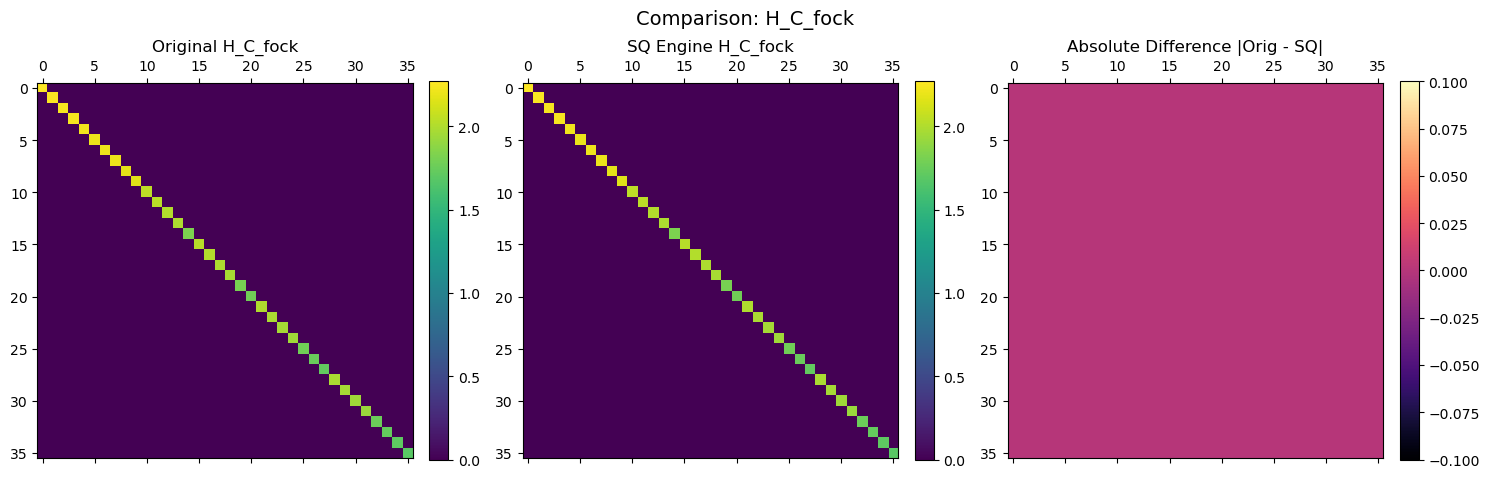

--- H_J_fock ---
  shape: orig=(36, 36)  sq=(36, 36)
  largest mismatch at index (2, 16)
    orig[2,16] = -1.072345e+00
    sq[2,16]   = -1.072345e+00+0.000000e+00j
  max absolute difference: 2.220e-16
  max |orig| (scale):      3.691e+00
  relative max difference: 6.017e-17



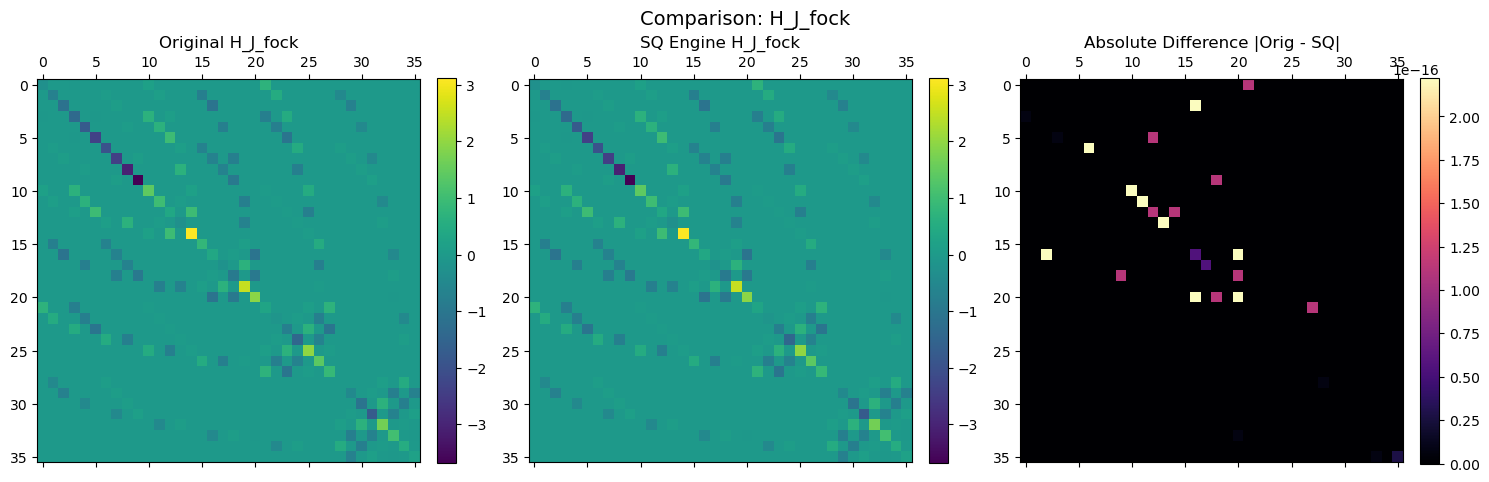

Computing Schrieffer-Wolff correction...
--- H_SW ---
  shape: orig=(144, 144)  sq=(144, 144)
  largest mismatch at index (0, 0)
    orig[0,0] = -1.409448e-03+0.000000e+00j
    sq[0,0]   = -1.409448e-03+0.000000e+00j
  max absolute difference: 0.000e+00
  max |orig| (scale):      1.402e-02
  relative max difference: 0.000e+00



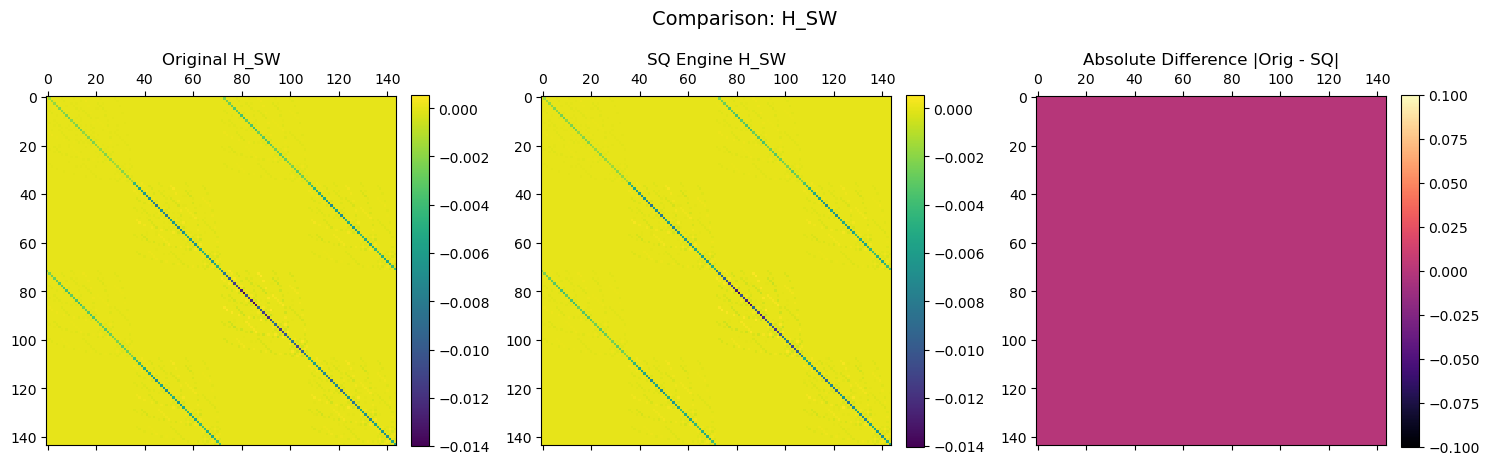

Done.


In [3]:
"""
Compares ssh_chain_single.py (original, matrix-conjugation based) against
ssh_chain_sq.py (sq_engine-based, Strategy A) at the Fock-space level:

  1. H_C_fock  -- capacitive Hamiltonian in the fixed-excitation basis
  2. H_J_fock  -- Josephson Hamiltonian in the fixed-excitation basis
  3. H_SW      -- second-order Schrieffer-Wolff correction in that same basis

For each, plots both matrices side by side plus their absolute
difference, and reports the location and magnitude of the largest
mismatch.
"""

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from ssh_chain_single import PHOTONICChain as PHOTONICChain_Original
from ssh_chain_sq import PHOTONICChain as PHOTONICChain_SQ


def to_dense(M):
    return M.toarray() if sp.issparse(M) else np.asarray(M)


def plot_matrix_comparison(M_orig, M_sq, title):
    M_orig = to_dense(M_orig).real
    M_sq   = to_dense(M_sq).real
    diff   = np.abs(M_orig - M_sq)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    im1 = axes[0].matshow(M_orig, cmap='viridis')
    axes[0].set_title(f"Original {title}")
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    im2 = axes[1].matshow(M_sq, cmap='viridis')
    axes[1].set_title(f"SQ Engine {title}")
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    im3 = axes[2].matshow(diff, cmap='magma')
    axes[2].set_title("Absolute Difference |Orig - SQ|")
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle(f"Comparison: {title}", fontsize=14)
    plt.tight_layout()
    plt.show()


def report_largest_mismatch(M_orig, M_sq, label):
    M_orig = to_dense(M_orig)
    M_sq   = to_dense(M_sq)
    diff   = np.abs(M_orig - M_sq)

    max_idx_flat = np.argmax(diff)
    row, col = np.unravel_index(max_idx_flat, diff.shape)
    max_diff = diff[row, col]
    scale = np.max(np.abs(M_orig))
    rel = max_diff / scale if scale > 0 else max_diff

    print(f"--- {label} ---")
    print(f"  shape: orig={M_orig.shape}  sq={M_sq.shape}")
    print(f"  largest mismatch at index ({row}, {col})")
    print(f"    orig[{row},{col}] = {M_orig[row, col]:.6e}")
    print(f"    sq[{row},{col}]   = {M_sq[row, col]:.6e}")
    print(f"  max absolute difference: {max_diff:.3e}")
    print(f"  max |orig| (scale):      {scale:.3e}")
    print(f"  relative max difference: {rel:.3e}")
    print()
    return row, col, max_diff, rel


def compare_fock_space_and_sw():
    N             = 4
    Omega_C       = 0.3
    Chi_C         = 0.5
    omega_r       = 0.13
    gamma         = 0.02
    fock_photon   = 4
    Omega_J       = 1.0
    Chi_J         = 0.0
    PBC           = False
    n_excitations = 2   # fixed excitation sector for both H_C/H_J and H_SW

    print("Initializing original implementation...")
    chain_orig = PHOTONICChain_Original(
        N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r,
        gamma=gamma, fock_photon=fock_photon, Omega_J=Omega_J, Chi_J=Chi_J, PBC=PBC
    )
    chain_orig.matter_hamiltonians(n_excitations=n_excitations)
    chain_orig.build_full_hamiltonian()

    print("Initializing sq_engine implementation...")
    chain_sq = PHOTONICChain_SQ(
        N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r,
        gamma=gamma, fock_photon=fock_photon, Omega_J=Omega_J, Chi_J=Chi_J, PBC=PBC, kerr = None
    )
    chain_sq.matter_hamiltonians(n_excitations=n_excitations)
    chain_sq.build_full_hamiltonian()

    print(f"\nfock_dim: orig={chain_orig.fock_dim}  sq={chain_sq.fock_dim}")
    same_basis = np.array_equal(chain_orig.fock_states, chain_sq.fock_states)
    print(f"fock_states identical ordering: {same_basis}")
    if not same_basis:
        print("WARNING: bases differ in ordering -- comparisons below assume identical "
              "row/column indexing and may be misleading if this is False.")

    # ------------------------------------------------------------------ #
    # 1. H_C_fock
    # ------------------------------------------------------------------ #
    report_largest_mismatch(chain_orig.H_C_fock, chain_sq.H_C_fock, "H_C_fock")
    plot_matrix_comparison(chain_orig.H_C_fock, chain_sq.H_C_fock, "H_C_fock")

    # ------------------------------------------------------------------ #
    # 2. H_J_fock
    # ------------------------------------------------------------------ #
    report_largest_mismatch(chain_orig.H_J_fock, chain_sq.H_J_fock, "H_J_fock")
    plot_matrix_comparison(chain_orig.H_J_fock, chain_sq.H_J_fock, "H_J_fock")

    # ------------------------------------------------------------------ #
    # 3. Schrieffer-Wolff correction, same fixed-excitation basis
    # ------------------------------------------------------------------ #
    print("Computing Schrieffer-Wolff correction...")
    chain_orig.schrieffer_wolff_correction()
    chain_sq.schrieffer_wolff_correction()

    report_largest_mismatch(chain_orig.H_SW, chain_sq.H_SW, "H_SW")
    plot_matrix_comparison(chain_orig.H_SW, chain_sq.H_SW, "H_SW")

    print("Done.")


if __name__ == "__main__":
    compare_fock_space_and_sw()